In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [2]:
centroids = ((-5,-5),(5,5),(-2.5,2.5),(2.5,-2.5))
cluster_std = [1,1,1,1]

In [3]:
X,y = make_blobs(n_samples=100,cluster_std=cluster_std,centers=centroids,n_features=2,random_state=2)

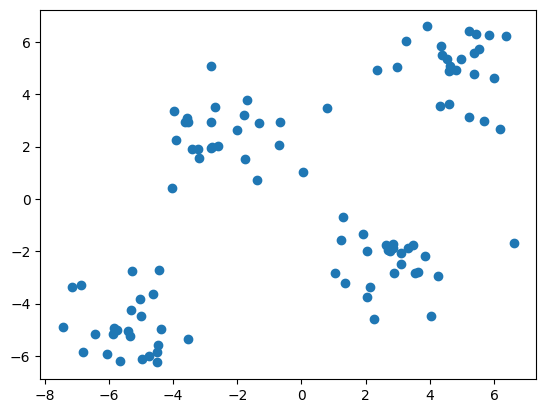

In [4]:
plt.scatter(X[:,0],X[:,1])
plt.show()

In [17]:
import random
import numpy as np

In [48]:

class KMeans:
    def __init__(self,n_clusters=2,max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self,X):
        random_index = random.sample(range(X.shape[0]),self.n_clusters)
        s = self.centroids = X[random_index]

        for i in range(self.max_iter):
            ## assing clusters
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids

            ## move centroids
            self.centroids = self.move_centroids(X,cluster_group)

            ## check finish
            if np.allclose(old_centroids, self.centroids):
                break
        return cluster_group 

    def assign_clusters(self,X):
        cluster_group = []

        distances = [] # append distance for 2 cluster

        for row in X:
            for centroid in self.centroids:
                distances.append(np.linalg.norm(row - centroid))
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()
        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):
        new_centroids = []
    
        for i in range(self.n_clusters):
            points = X[cluster_group == i]
    
            if len(points) == 0:
                # Keep the old centroid if no points are assigned
                new_centroids.append(self.centroids[i])
            else:
                new_centroids.append(points.mean(axis=0))
    
        return np.array(new_centroids)
        
    def calculate_wcss(self, X, cluster_group):

        wcss = 0

        for i in range(self.n_clusters):

            points = X[cluster_group == i]

            for point in points:
                wcss += np.sum((point - self.centroids[i]) ** 2)

        return wcss

In [22]:
km = KMeans(n_clusters=4,max_iter=200)

In [23]:
y_means = km.fit_predict(X)

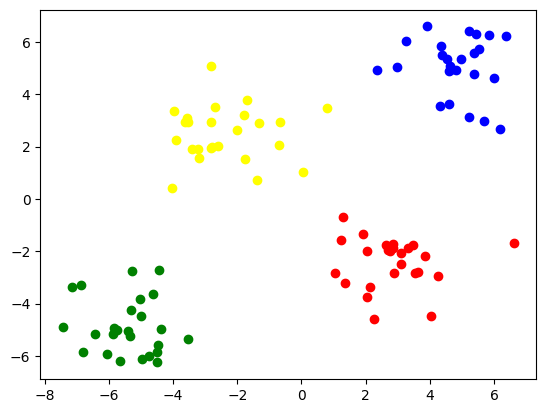

In [24]:
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color="red")
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color="blue")
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color="green")
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color="yellow")

In [38]:
## find the distance

a = np.array([1,2])
b = np.array([3,4])
print(np.sqrt(np.dot(b-a,b-a)))
print(np.linalg.norm(b-a))

2.8284271247461903
2.8284271247461903


In [39]:
x = np.array([[1,2],[2,3],[3,4],[4,5],[5,6]])

In [40]:
x

array([[1, 2],
       [2, 3],
       [3, 4],
       [4, 5],
       [5, 6]])

In [41]:
cluster_group = np.array([0,1,1,0,0])

In [42]:
clusters_type = np.unique(cluster_group)
clusters_type

array([0, 1])

In [43]:
for i in clusters_type:
    print(x[cluster_group == i].mean(axis=1))

[1.5 4.5 5.5]
[2.5 3.5]


In [44]:
x[cluster_group == i].mean(axis=1)

array([2.5, 3.5])

## kmeans from real student data

In [49]:
import pandas as pd

In [50]:
df = pd.read_csv("./student.csv")

In [51]:
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


In [52]:
X = df.iloc[:,:].values

In [53]:
km = KMeans(n_clusters=4)

In [54]:
y_means = km.fit_predict(X)

In [55]:
y_means

array([3, 1, 0, 0, 1, 1, 0, 1, 1, 0, 3, 1, 0, 3, 1, 0, 1, 0, 1, 1, 0, 3,
       0, 3, 3, 0, 3, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 0, 3,
       1, 1, 0, 1, 1, 1, 2, 3, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 3, 1,
       0, 2, 1, 0, 1, 1, 0, 2, 1, 1, 1, 1, 3, 0, 0, 1, 1, 2, 1, 3, 1, 1,
       1, 1, 1, 1, 0, 3, 0, 0, 1, 0, 3, 1, 1, 3, 3, 1, 3, 3, 0, 3, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 3, 3, 1, 0, 1, 0, 2, 0, 1, 3, 0, 0, 1,
       2, 3, 1, 1, 1, 3, 0, 0, 0, 2, 1, 3, 3, 1, 3, 1, 1, 3, 1, 2, 1, 1,
       3, 0, 1, 1, 1, 0, 3, 1, 1, 0, 1, 3, 1, 2, 3, 1, 1, 1, 1, 3, 3, 0,
       1, 1, 3, 1, 1, 1, 1, 1, 0, 3, 0, 0, 1, 1, 0, 0, 3, 2, 0, 3, 1, 1,
       1, 1])

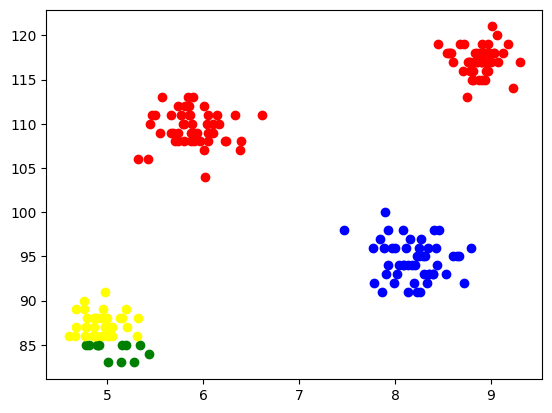

In [56]:
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color="blue")
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color="red")
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color="green")
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color="yellow")

In [57]:
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, max_iter=100)
    labels = km.fit_predict(X)
    wcss.append(km.calculate_wcss(X, labels))

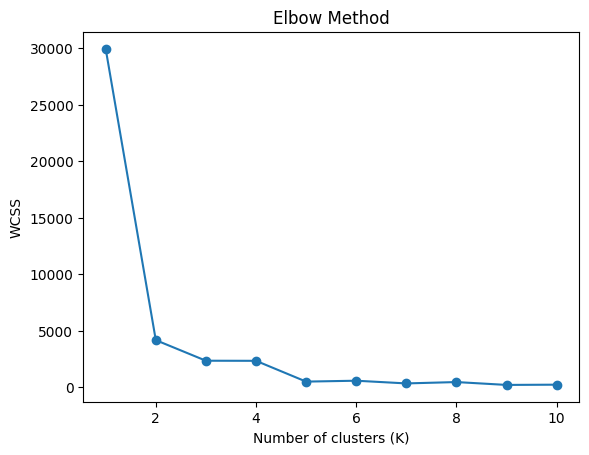

In [58]:
import matplotlib.pyplot as plt

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()